In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("dataset11.csv")

In [20]:
df

,Country,Broadband Speed Rank,Broadband Mbps,Mobile Speed Rank,Mobile Mbps,As of
0,Monaco,1.0,192.68,NaN,NaN,January 2022
1,Singapore,2.0,192.01,19.0,64.92,January 2022
2,Chile,3.0,189.36,109.0,15.50,January 2022
3,Thailand,4.0,184.03,56.0,32.38,January 2022
4,Hong Kong (SAR),5.0,173.42,38.0,45.86,January 2022
...,...,...,...,...,...,...
174,Yemen,175.0,2.74,140.0,0.53,January 2022
175,Ethiopia,176.0,2.69,78.0,22.83,January 2022
176,Cuba,177.0,1.90,119.0,12.71,January 2022
177,Turkmenistan,178.0,1.89,139.0,3.09,January 2022


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               179 non-null    object 
 1   Broadband Speed Rank  179 non-null    float64
 2   Broadband Mbps        179 non-null    float64
 3   Mobile Speed Rank     139 non-null    float64
 4   Mobile Mbps           139 non-null    float64
 5   As of                 179 non-null    object 
dtypes: float64(4), object(2)
memory usage: 8.5+ KB


In [22]:
df.isnull().sum()

Country                  0
Broadband Speed Rank     0
Broadband Mbps           0
Mobile Speed Rank       40
Mobile Mbps             40
As of                    0
dtype: int64

In [23]:
df['Broadband Mbps'] = df['Broadband Mbps'].fillna(df['Broadband Mbps'].mean())
df['Mobile Mbps'] = df['Mobile Mbps'].fillna(df['Mobile Mbps'].mean())

In [24]:
df = df.fillna(0)

In [25]:
df = df.drop_duplicates()

In [26]:
df = df.sort_values(by='Broadband Mbps', ascending=False)

In [27]:
df

,Country,Broadband Speed Rank,Broadband Mbps,Mobile Speed Rank,Mobile Mbps,As of
0,Monaco,1.0,192.68,0.0,34.885324,January 2022
1,Singapore,2.0,192.01,19.0,64.920000,January 2022
2,Chile,3.0,189.36,109.0,15.500000,January 2022
3,Thailand,4.0,184.03,56.0,32.380000,January 2022
4,Hong Kong (SAR),5.0,173.42,38.0,45.860000,January 2022
...,...,...,...,...,...,...
174,Yemen,175.0,2.74,140.0,0.530000,January 2022
175,Ethiopia,176.0,2.69,78.0,22.830000,January 2022
176,Cuba,177.0,1.90,119.0,12.710000,January 2022
177,Turkmenistan,178.0,1.89,139.0,3.090000,January 2022


In [28]:
df.isnull().sum()

Country                 0
Broadband Speed Rank    0
Broadband Mbps          0
Mobile Speed Rank       0
Mobile Mbps             0
As of                   0
dtype: int64

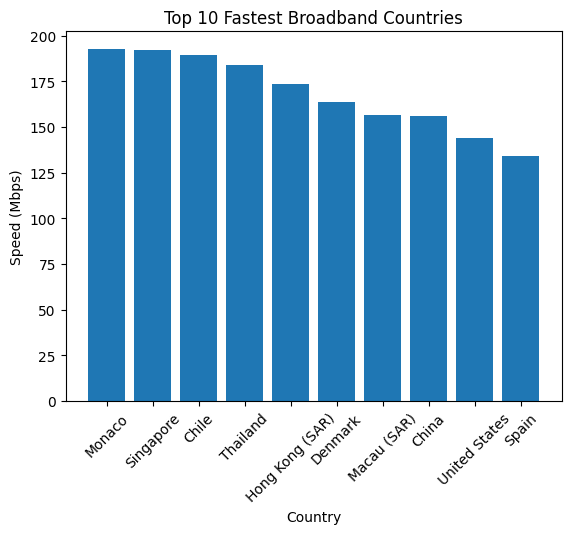

<Figure size 640x480 with 0 Axes>

In [34]:
top10 = df.head(10)

plt.figure()
plt.bar(top10['Country'], top10['Broadband Mbps'])
plt.xticks(rotation=45)
plt.title("Top 10 Fastest Broadband Countries")
plt.xlabel("Country")
plt.ylabel("Speed (Mbps)")
plt.show()
plt.savefig("top 10 fastest.png")

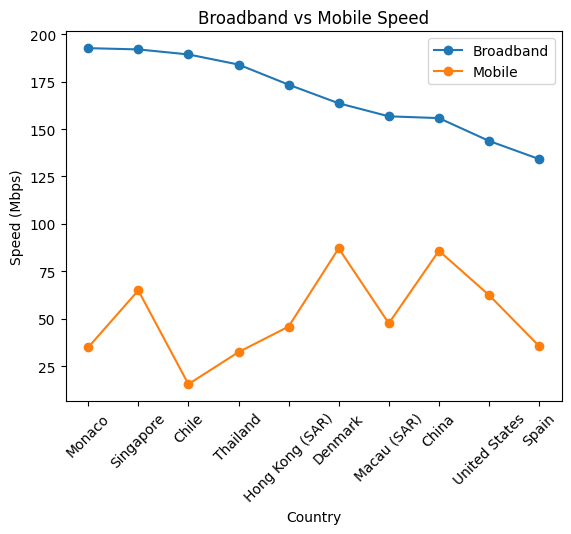

<Figure size 640x480 with 0 Axes>

In [40]:
top10 = df.head(10)

plt.figure()
plt.plot(top10['Country'], top10['Broadband Mbps'], marker='o')
plt.plot(top10['Country'], top10['Mobile Mbps'], marker='o')

plt.xticks(rotation=45)
plt.title("Broadband vs Mobile Speed")
plt.xlabel("Country")
plt.ylabel("Speed (Mbps)")
plt.legend(["Broadband", "Mobile"])

plt.show()
plt.savefig("bro.png")

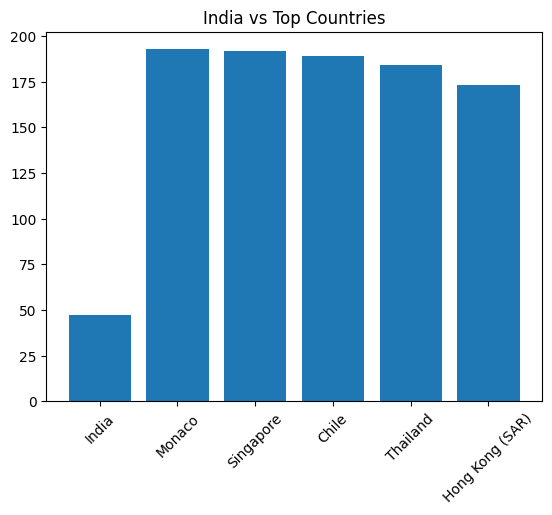

<Figure size 640x480 with 0 Axes>

In [36]:
india = df[df['Country'] == 'India']
top5 = df.head(5)

compare = pd.concat([india, top5])

plt.figure()
plt.bar(compare['Country'], compare['Broadband Mbps'])
plt.title("India vs Top Countries")
plt.xticks(rotation=45)
plt.show()
plt.savefig("india vs top.png")

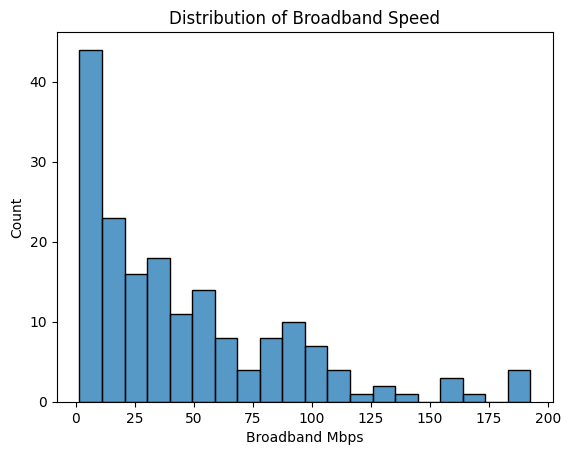

<Figure size 640x480 with 0 Axes>

In [37]:
plt.figure()
sns.histplot(df['Broadband Mbps'], bins=20)
plt.title("Distribution of Broadband Speed")
plt.show()
plt.savefig("dist.png")

In [39]:


# 1 Top 10 Broadband
top10 = df.sort_values(by="Broadband Mbps", ascending=False).head(10)
plt.figure(figsize=(8,4))
plt.bar(top10["Country"], top10["Broadband Mbps"])
plt.xticks(rotation=45)
plt.title("Top 10 Broadband")
plt.tight_layout()
plt.savefig("top10_broadband.png")
plt.close()

# 2 Top 10 Mobile
top10m = df.sort_values(by="Mobile Mbps", ascending=False).head(10)
plt.figure(figsize=(8,4))
plt.bar(top10m["Country"], top10m["Mobile Mbps"])
plt.xticks(rotation=45)
plt.title("Top 10 Mobile")
plt.tight_layout()
plt.savefig("top10_mobile.png")
plt.close()

# 3 Scatter
plt.scatter(df["Broadband Mbps"], df["Mobile Mbps"])
plt.xlabel("Broadband")
plt.ylabel("Mobile")
plt.title("Broadband vs Mobile")
plt.savefig("scatter.png")
plt.close()

# 4 Histogram
plt.hist(df["Broadband Mbps"], bins=20)
plt.title("Speed Distribution")
plt.savefig("hist.png")
plt.close()

# 5 Pie
top5 = top10.head(5)
plt.pie(top5["Broadband Mbps"], labels=top5["Country"], autopct="%1.1f%%")
plt.title("Top 5 Share")
plt.savefig("pie.png")
plt.close()

# 6 Bottom 10
bottom10 = df.sort_values(by="Broadband Mbps").head(10)
plt.bar(bottom10["Country"], bottom10["Broadband Mbps"])
plt.xticks(rotation=45)
plt.title("Bottom 10 Countries")
plt.savefig("bottom10.png")
plt.close()

# 7 Avg comparison
avg = df[["Broadband Mbps","Mobile Mbps"]].mean()
plt.bar(["Broadband","Mobile"], avg)
plt.title("Average Speed")
plt.savefig("avg.png")
plt.close()

# 8 Rank vs Speed
plt.plot(df["Broadband Speed Rank"], df["Broadband Mbps"])
plt.title("Rank vs Speed")
plt.savefig("rank.png")
plt.close()

# 9 Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.savefig("heatmap.png")
plt.close()

# 10 Boxplot
sns.boxplot(df["Broadband Mbps"])
plt.title("Outliers")
plt.savefig("box.png")
plt.close()